# Notebook 00 — Setup y Verificación del Dataset

**Proyecto:** Clasificación de ensayos EEG [match vs mismatch].  
Track elegido: Track A - ML Clásico  
**Autores:** Jose Pablo Agüero Mora, Roilin Navarro Vargas

## Objetivo

Punto de partida del pipeline. No procesa datos todavía — solo:

1. Instala dependencias.
2. Monta Google Drive.
3. Carga la configuración global desde configs/main_config.yaml.
4. Verifica la estructura del dataset.
5. Determina qué contienen los archivos _allepochs.set con esto se define el Notebook 01.
6. Cuenta epochs por sujeto y condición.
7. Sanity check visual del ERP promedio.

## Salida

- `reports/00_dataset_inventory.json`
- `reports/00_epochs_per_subject.csv`
- `figures/00_erp_sanity_<subject>.png`


## 1. Configuración

In [13]:
# ============================================================
# Ruta del repo
# ============================================================
PROJECT_ROOT_DRIVE = '/content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400'

# Sujeto de muestra para inspección (debe estar en Included)
SAMPLE_SUBJECT = 'mu02erp'

# Forzar re-ejecución completa aunque las salidas ya existan
FORCE_RERUN = True

print(f'PROJECT_ROOT_DRIVE: {PROJECT_ROOT_DRIVE}')
print(f'SAMPLE_SUBJECT:     {SAMPLE_SUBJECT}')
print(f'FORCE_RERUN:        {FORCE_RERUN}')

PROJECT_ROOT_DRIVE: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400
SAMPLE_SUBJECT:     mu02erp
FORCE_RERUN:        True


## 2. Instalación de dependencias

Versiones fijadas en requirements.txt.

In [2]:
%%capture
!pip install -q --upgrade --no-cache-dir shap>=0.46.0
!pip install -q mne==1.12.1
!pip install -q scikit-learn xgboost lightgbm optuna
!pip install -q pyxdf openpyxl pyyaml tqdm jedi

In [ ]:
import os
os.kill(os.getpid(), 9)

In [14]:
import os
import sys
import json
import yaml
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
mne.set_log_level("WARNING")

import sklearn
import xgboost
import lightgbm
import optuna
import shap

print(f"Python:       {sys.version.split()[0]}")
print(f"NumPy:        {np.__version__}")
print(f"Pandas:       {pd.__version__}")
print(f"MNE-Python:   {mne.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"XGBoost:      {xgboost.__version__}")
print(f"LightGBM:     {lightgbm.__version__}")
print(f"Optuna:       {optuna.__version__}")
print(f"SHAP:         {shap.__version__}")

Python:       3.12.13
NumPy:        2.0.2
Pandas:       2.2.2
MNE-Python:   1.12.1
scikit-learn: 1.6.1
XGBoost:      3.2.0
LightGBM:     4.6.0
Optuna:       4.8.0
SHAP:         0.52.0


## 3. Montaje de Google Drive

In [15]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

assert os.path.exists(PROJECT_ROOT_DRIVE), (
    f'No existe PROJECT_ROOT_DRIVE: {PROJECT_ROOT_DRIVE}\n'
)
print(f'Drive preparado correctamente.')
print(f'\nContenido de {PROJECT_ROOT_DRIVE}:')
for item in sorted(os.listdir(PROJECT_ROOT_DRIVE)):
    marker = '/' if os.path.isdir(os.path.join(PROJECT_ROOT_DRIVE, item)) else ''
    print(f'  - {item}{marker}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive preparado correctamente.

Contenido de /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400:
  - .gitignore
  - LICENSE
  - README.md
  - configs/
  - dataset/
  - docs/
  - features/
  - figures/
  - logs/
  - models/
  - notebooks/
  - readme/
  - reports/
  - requirements.txt
  - src/


## 4. Carga de la configuración global

Todos los parámetros del pipeline están en configs/main_config.yaml.

In [16]:
CONFIG_PATH = Path(PROJECT_ROOT_DRIVE) / 'configs' / 'main_config.yaml'

assert CONFIG_PATH.exists(), (
    f'No se encontró {CONFIG_PATH}.\n'
    f'Verificar que el repo esté completo en {PROJECT_ROOT_DRIVE}.'
)

with open(CONFIG_PATH, 'r') as f:
    CFG = yaml.safe_load(f)

print(f'OK: configuración cargada desde {CONFIG_PATH}')
print(f'\nSemilla global:   {CFG["seed"]}')
print(f'Canales:          {CFG["data"]["channels"]}')
print(f'sfreq:            {CFG["data"]["sfreq"]} Hz')
print(f'Epoch window:     {CFG["preprocessing"]["epoch_tmin"]*1000:.0f} a {CFG["preprocessing"]["epoch_tmax"]*1000:.0f} ms')
print(f'Baseline:         {CFG["preprocessing"]["baseline_tmin"]*1000:.0f} a {CFG["preprocessing"]["baseline_tmax"]*1000:.0f} ms')
print(f'N400 window:      {CFG["n400"]["window_tmin"]*1000:.0f} a {CFG["n400"]["window_tmax"]*1000:.0f} ms')

# Fijar semillas globales
SEED = CFG['seed']
random.seed(SEED)
np.random.seed(SEED)

# Rutas absolutas
DATASET_ROOT = Path(CFG['paths']['dataset_root'])
REPORTS_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['reports_dir']
FIGURES_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['figures_dir']
FEATURES_DIR = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['features_dir']
MODELS_DIR   = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['models_dir']
LOGS_DIR     = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['logs_dir']

for d in [REPORTS_DIR, FIGURES_DIR, FEATURES_DIR, MODELS_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'\nDATASET_ROOT: {DATASET_ROOT}')
print(f'Dataset existe: {DATASET_ROOT.exists()}')
assert DATASET_ROOT.exists(), f'No existe DATASET_ROOT: {DATASET_ROOT}'

OK: configuración cargada desde /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/configs/main_config.yaml

Semilla global:   42
Canales:          ['AF7', 'AF8']
sfreq:            256 Hz
Epoch window:     -100 a 900 ms
Baseline:         -100 a 0 ms
N400 window:      250 a 600 ms

DATASET_ROOT: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/dataset
Dataset existe: True


## 5. ¿Ya se ejecutó este notebook?

Si el inventario ya existe y FORCE_RERUN=False, salta las inspecciones.

In [17]:
INVENTORY_PATH = REPORTS_DIR / '00_dataset_inventory.json'

if INVENTORY_PATH.exists() and not FORCE_RERUN:
    print(f'Ya existe el inventario en {INVENTORY_PATH}')
    with open(INVENTORY_PATH, 'r') as f:
        inventory = json.load(f)
    print(f'\nEscenario detectado previamente: {inventory.get("scenario")}')
    SKIP_REST = True
else:
    inventory = {}
    SKIP_REST = False
    print('Ejecución completa: no existe inventario previo o se pidió rerun.')

Ejecución completa: no existe inventario previo o se pidió rerun.


## 6. Inventario estructural del dataset

Verifica que están las piezas esperadas del dataset:
- 37 sujetos en BIDS
- 29 sujetos en Included, 8 en Excluded
- Archivos conductuales por sujeto

In [18]:
if not SKIP_REST:
    P_BIDS       = DATASET_ROOT / 'EEG Data' / 'Raw EEG' / 'BIDS'
    P_INCLUDED   = DATASET_ROOT / 'EEG Data' / 'Processed EEG' / 'Included'
    P_EXCLUDED   = DATASET_ROOT / 'EEG Data' / 'Processed EEG' / 'Excluded'
    P_BEHAVIORAL = DATASET_ROOT / 'Behavioral Data'
    P_DEMOG      = P_BEHAVIORAL / 'Muse_Demographics.xlsx'

    bids_subjects   = sorted([d.name for d in P_BIDS.glob('sub-mu*') if d.is_dir()])
    included_files  = sorted([f.name for f in P_INCLUDED.glob('*allepochs.set')])
    excluded_files  = sorted([f.name for f in P_EXCLUDED.glob('*allepochs.set')])
    behavioral_csvs = sorted([f.name for f in P_BEHAVIORAL.glob('MU*_SRJT_Resp.csv')])

    inventory.update({
        'bids_n_subjects': len(bids_subjects),
        'bids_subjects': bids_subjects,
        'included_n': len(included_files),
        'excluded_n': len(excluded_files),
        'included_files': included_files,
        'excluded_files': excluded_files,
        'behavioral_n': len(behavioral_csvs),
        'demographics_exists': P_DEMOG.exists(),
    })

    print('=== INVENTARIO DEL DATASET ===')
    print(f'BIDS:        {inventory["bids_n_subjects"]:>3} sujetos  (esperado: 37)')
    print(f'Included:    {inventory["included_n"]:>3} archivos  (esperado: 29)')
    print(f'Excluded:    {inventory["excluded_n"]:>3} archivos  (esperado:  8)')
    print(f'Behavioral:  {inventory["behavioral_n"]:>3} CSVs      (esperado: 37)')
    print(f'Demographics xlsx existe: {inventory["demographics_exists"]}')

    warnings = []
    if inventory['bids_n_subjects'] != 37: warnings.append(f'BIDS: {inventory["bids_n_subjects"]} ≠ 37')
    if inventory['included_n']      != 29: warnings.append(f'Included: {inventory["included_n"]} ≠ 29')
    if inventory['excluded_n']      !=  8: warnings.append(f'Excluded: {inventory["excluded_n"]} ≠ 8')
    if inventory['behavioral_n']    != 37: warnings.append(f'Behavioral: {inventory["behavioral_n"]} ≠ 37')

    if warnings:
        print('\nADVERTENCIAS:')
        for w in warnings:
            print(f'  - {w}')
    else:
        print('\nEl inventario está completo.')

=== INVENTARIO DEL DATASET ===
BIDS:         37 sujetos  (esperado: 37)
Included:     29 archivos  (esperado: 29)
Excluded:      8 archivos  (esperado:  8)
Behavioral:   37 CSVs      (esperado: 37)
Demographics xlsx existe: True

El inventario está completo.


## 7. Inspección para verificar el contenido de los _allepochs.set

- Escenario A: epochs ya extraídas.
- Escenario B: señal continua con marcas, nos toca hacer los epochs.

Probamos primero como Epochs. Si falla, probamos como Raw.

In [19]:
if not SKIP_REST:
    sample_filename = f'{SAMPLE_SUBJECT} srjt_allepochs.set'
    sample_path = P_INCLUDED / sample_filename
    assert sample_path.exists(), f'No existe: {sample_path}'
    print(f'Inspeccionando: {sample_path}\n')

    scenario = None
    epochs = None
    raw = None

    try:
        epochs = mne.io.read_epochs_eeglab(str(sample_path), verbose='ERROR')
        scenario = 'A_epochs'
        print('ESCENARIO A — el archivo CONTIENE EPOCHS YA EXTRAÍDAS.')
    except Exception as e_ep:
        print(f'No se pudo leer como Epochs: {type(e_ep).__name__}')
        print(f'   Detalle: {str(e_ep)[:200]}')
        print('Intentando como señal continua (Raw)\n')
        try:
            raw = mne.io.read_raw_eeglab(str(sample_path), preload=True, verbose='ERROR')
            scenario = 'B_continuous'
            print('ESCENARIO B — el archivo es SEÑAL CONTINUA.')
        except Exception as e_raw:
            scenario = 'ERROR'
            print(f'FALLO también como Raw: {type(e_raw).__name__}: {e_raw}')
            raise

    inventory['scenario'] = scenario

Inspeccionando: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/dataset/EEG Data/Processed EEG/Included/mu02erp srjt_allepochs.set

ESCENARIO A — el archivo CONTIENE EPOCHS YA EXTRAÍDAS.


In [20]:
if not SKIP_REST and scenario == 'A_epochs':
    print('=== METADATA DE LAS EPOCHS ===')
    print(f'n_epochs:     {len(epochs)}')
    print(f'n_channels:   {len(epochs.ch_names)}')
    print(f'ch_names:     {epochs.ch_names}')
    print(f'sfreq:        {epochs.info["sfreq"]} Hz')
    print(f'tmin:         {epochs.tmin*1000:.1f} ms')
    print(f'tmax:         {epochs.tmax*1000:.1f} ms')
    print(f'n_times:      {len(epochs.times)} muestras/epoch')
    print(f'baseline:     {epochs.baseline}')
    print(f'event_id:     {epochs.event_id}')

    print(f'\nDistribución de eventos:')
    id_to_name = {v: k for k, v in epochs.event_id.items()}
    events_counter = Counter(epochs.events[:, 2])
    for code, count in sorted(events_counter.items()):
        print(f'  {id_to_name.get(code, str(code)):25s} - {count}')

    inventory['scenario_A_details'] = {
        'n_epochs':   int(len(epochs)),
        'n_channels': len(epochs.ch_names),
        'ch_names':   epochs.ch_names,
        'sfreq':      float(epochs.info['sfreq']),
        'tmin_ms':    float(epochs.tmin * 1000),
        'tmax_ms':    float(epochs.tmax * 1000),
        'n_times':    int(len(epochs.times)),
        'baseline':   None if epochs.baseline is None else [float(x) for x in epochs.baseline],
        'event_id':   {k: int(v) for k, v in epochs.event_id.items()},
        'event_counts_in_sample': {id_to_name.get(int(c), str(c)): int(n) for c, n in events_counter.items()},
    }

elif not SKIP_REST and scenario == 'B_continuous':
    print('=== METADATA DE LA SEÑAL CONTINUA ===')
    print(f'duración:     {raw.times[-1]:.1f} s')
    print(f'n_channels:   {len(raw.ch_names)}')
    print(f'ch_names:     {raw.ch_names}')
    print(f'sfreq:        {raw.info["sfreq"]} Hz')
    try:
        events, event_id = mne.events_from_annotations(raw, verbose='ERROR')
        id_to_name = {v: k for k, v in event_id.items()}
        events_counter = Counter(events[:, 2])
        print('\nEventos:')
        for code, count in sorted(events_counter.items()):
            print(f'  {id_to_name.get(code, str(code)):25s} → {count}')
        inventory['scenario_B_details'] = {
            'duration_s': float(raw.times[-1]),
            'n_channels': len(raw.ch_names),
            'ch_names':   raw.ch_names,
            'sfreq':      float(raw.info['sfreq']),
            'event_id':   {k: int(v) for k, v in event_id.items()},
            'event_counts': {id_to_name.get(int(c), str(c)): int(n) for c, n in events_counter.items()},
        }
    except Exception as e:
        print(f'No se pudieron extraer eventos: {e}')

=== METADATA DE LAS EPOCHS ===
n_epochs:     95
n_channels:   2
ch_names:     ['AF7', 'AF8']
sfreq:        256.0 Hz
tmin:         -101.6 ms
tmax:         894.5 ms
n_times:      256 muestras/epoch
baseline:     None
event_id:     {'matchTarget/Correct': 1, 'mismatchTarget/Correct': 2, 'mismatchTarget': 3, 'matchTarget': 4}

Distribución de eventos:
  matchTarget/Correct       - 33
  mismatchTarget/Correct    - 13
  mismatchTarget            - 33
  matchTarget               - 16


## 8. Sanity check visual (ERP promedio)

Si la N400 existe en este sujeto, se espera ver una diferencia entre matchTarget y mismatchTarget alrededor de 400 ms, especialmente en AF8 (canal donde Hayes & Magne 2024 reportaron el cluster significativo).

Eventos disponibles: ['matchTarget/Correct', 'mismatchTarget/Correct', 'mismatchTarget', 'matchTarget']
match_key:    matchTarget/Correct
mismatch_key: mismatchTarget/Correct

Figura guardada: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/00_erp_sanity_mu02erp.png


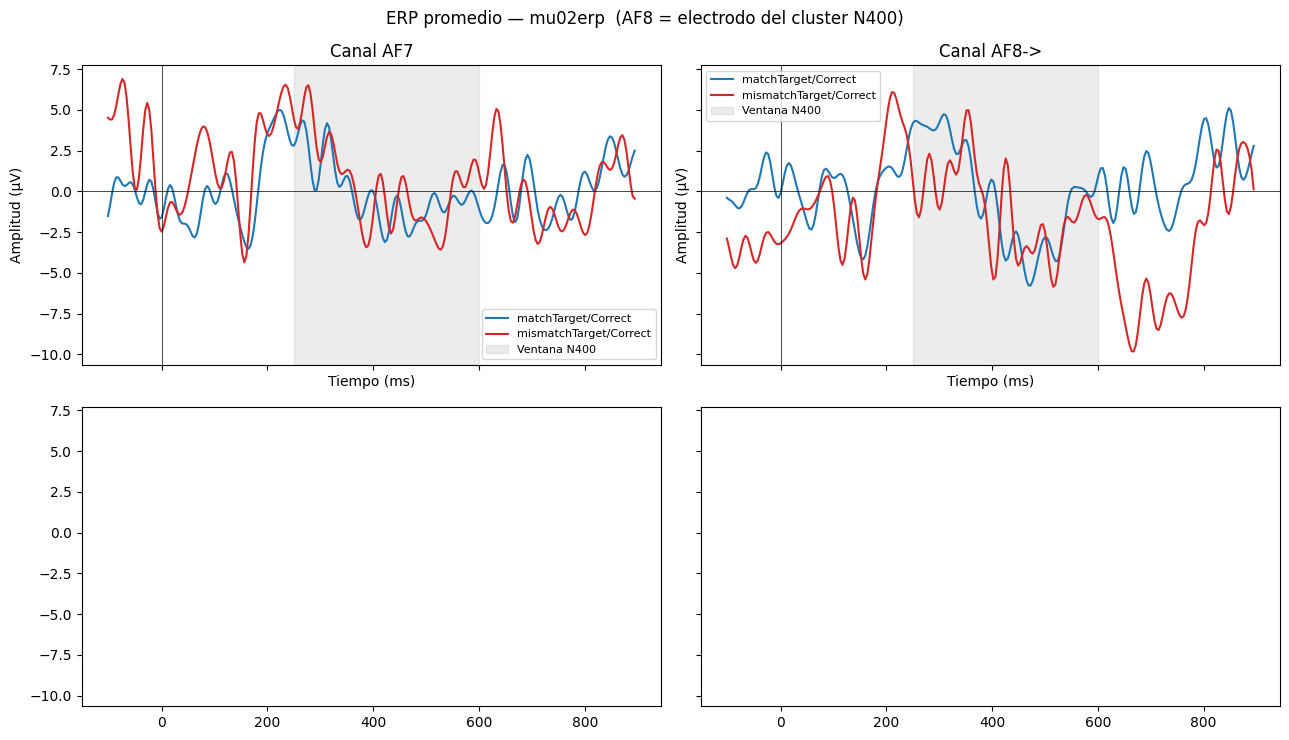

In [21]:
if not SKIP_REST and scenario == 'A_epochs':
    available = list(epochs.event_id.keys())
    print(f'Eventos disponibles: {available}')

    match_key    = next((k for k in available if 'match' in k.lower() and 'mis' not in k.lower() and 'target' in k.lower()), None)
    mismatch_key = next((k for k in available if 'mismatch' in k.lower() and 'target' in k.lower()), None)
    if match_key is None:
        match_key = next((k for k in available if k.lower() == 'match'), None)
    if mismatch_key is None:
        mismatch_key = next((k for k in available if k.lower() == 'mismatch'), None)

    print(f'match_key:    {match_key}')
    print(f'mismatch_key: {mismatch_key}')

    if match_key and mismatch_key:
        evoked_match    = epochs[match_key].average()
        evoked_mismatch = epochs[mismatch_key].average()

        n400_t1 = CFG['n400']['window_tmin'] * 1000
        n400_t2 = CFG['n400']['window_tmax'] * 1000

        fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharex=True, sharey=True)
        for ax, ch in zip(axes.flat, epochs.ch_names[:4]):
            ch_idx = epochs.ch_names.index(ch)
            ax.plot(evoked_match.times * 1000,
                    evoked_match.data[ch_idx] * 1e6,
                    label=match_key, color='tab:blue', linewidth=1.5)
            ax.plot(evoked_mismatch.times * 1000,
                    evoked_mismatch.data[ch_idx] * 1e6,
                    label=mismatch_key, color='tab:red', linewidth=1.5)
            ax.axvspan(n400_t1, n400_t2, color='gray', alpha=0.15, label='Ventana N400')
            ax.axvline(0, color='k', linewidth=0.5)
            ax.axhline(0, color='k', linewidth=0.5)
            title_extra = '->' if ch == 'AF8' else ''
            ax.set_title(f'Canal {ch}{title_extra}')
            ax.set_xlabel('Tiempo (ms)')
            ax.set_ylabel('Amplitud (µV)')
            ax.legend(loc='best', fontsize=8)
            ax.invert_yaxis()
        plt.suptitle(f'ERP promedio — {SAMPLE_SUBJECT}  (AF8 = electrodo del cluster N400)', fontsize=12)
        plt.tight_layout()

        fig_path = FIGURES_DIR / f'00_erp_sanity_{SAMPLE_SUBJECT}.png'
        plt.savefig(fig_path, dpi=120, bbox_inches='tight')
        print(f'\nFigura guardada: {fig_path}')
        plt.show()
    else:
        print('No se encontraron eventos match/mismatch claros — revisar nombres.')

## 9. Conteo de epochs por sujeto en Included

In [22]:
if not SKIP_REST and scenario == 'A_epochs':
    from tqdm.auto import tqdm

    per_subject_counts = {}
    failed_subjects = []

    for fname in tqdm(included_files, desc='Cargando sujetos Included'):
        subj_id = fname.split(' ')[0]
        try:
            ep = mne.io.read_epochs_eeglab(str(P_INCLUDED / fname), verbose='ERROR')
            id_to_name = {v: k for k, v in ep.event_id.items()}
            counts = Counter(id_to_name[c] for c in ep.events[:, 2])
            per_subject_counts[subj_id] = dict(counts)
        except Exception as e:
            failed_subjects.append((subj_id, str(e)[:120]))

    print(f'\nSujetos correctos cargados: {len(per_subject_counts)}')
    print(f'Sujetos con error:   {len(failed_subjects)}')
    if failed_subjects:
        for s, e in failed_subjects:
            print(f'  {s}: {e}')

    rows = []
    for subj, cnt in per_subject_counts.items():
        row = {'subject': subj}
        row.update(cnt)
        row['total'] = sum(cnt.values())
        rows.append(row)
    df_counts = pd.DataFrame(rows).fillna(0).sort_values('subject').reset_index(drop=True)
    for col in df_counts.columns:
        if col != 'subject':
            df_counts[col] = df_counts[col].astype(int)

    print('\n=== EPOCHS POR SUJETO ===')
    print(df_counts.to_string(index=False))
    print('\n=== TOTALES POR EVENTO ===')
    print(df_counts.drop(columns=['subject','total']).sum().to_string())

    counts_path = REPORTS_DIR / '00_epochs_per_subject.csv'
    df_counts.to_csv(counts_path, index=False)
    print(f'\nGuardado: {counts_path}')

    inventory['per_subject_event_counts'] = per_subject_counts
    inventory['failed_subjects_in_load']  = failed_subjects

Cargando sujetos Included:   0%|          | 0/29 [00:00<?, ?it/s]


Sujetos correctos cargados: 29
Sujetos con error:   0

=== EPOCHS POR SUJETO ===
subject  matchTarget/Correct  mismatchTarget/Correct  mismatchTarget  matchTarget  total  mismatchTarget/Incorrect  matchTarget/Incorrect  matchTarget/Correct/mismatch/mismatchTarget/Correct/mismatch/mismatchTarget/Correct/mismatch/mismatchTarget/Correct/match/matchTarget/Correct/match/matchTarget/Correct/match/matchTarget/Correct/match/matchTarget/Correct/mismatch/mismatchTarget  mismatchTarget/Correct/match/matchTarget/Incorrect/mismatch/mismatchTarget/Correct/mismatch/mismatchTarget/Correct/mismatch/mismatchTarget/Correct/match/matchTarget/Correct/match/matchTarget/Incorrect/match/matchTarget/Correct/match/matchTarget/Correct/match/matchTarget/Correct/mismatch/mismatchTarget/Correct/match  mismatchTarget/Correct/match/matchTarget/Correct/mismatch/mismatchTarget/Correct/match/matchTarget/Correct/match/matchTarget/Correct/match/matchTarget/Correct/mismatch/mismatchTarget/Correct/match/matchTarget  Correc